# 02 — Encoding
Genera representaciones vectoriales de los tweets preprocesados: Bag of Words, TF-IDF unigrama y TF-IDF bigrama. Las matrices se guardan en `data/encoded/` para ser reutilizadas por los notebooks de modelos.

In [2]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import joblib
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv()

RANDOM_SEED = int(os.getenv('RANDOM_SEED', 42))
np.random.seed(RANDOM_SEED)

DATA_PROCESSED = Path('../data/processed')
DATA_ENCODED   = Path('../data/encoded')
DATA_ENCODED.mkdir(parents=True, exist_ok=True)

print('Setup complete')

Setup complete


## Carga de datos procesados

In [3]:
df_train = pd.read_parquet(DATA_PROCESSED / 'train_clean.parquet')
df_test  = pd.read_parquet(DATA_PROCESSED / 'test_clean.parquet')

X_train = df_train['text_clean'].fillna('').values
y_train = df_train['label'].values
X_test  = df_test['text_clean'].fillna('').values
y_test  = df_test['label'].values

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# Load best config for reference
with open(DATA_PROCESSED / 'best_preproc_config.json') as f:
    best_config = json.load(f)
print('Preprocessing config used:', best_config)

Train: 1,360,000 | Test: 240,000
Preprocessing config used: {'remove_stopwords': False, 'lemmatize': False, 'emoji_mode': 'drop', 'normalize_elongations_flag': False, 'remove_punct': True}


## Encoding 1 — Bag of Words (CountVectorizer)

In [4]:
bow_vec = CountVectorizer(max_features=50000, min_df=2)
X_train_bow = bow_vec.fit_transform(X_train)
X_test_bow  = bow_vec.transform(X_test)

sp.save_npz(DATA_ENCODED / 'X_train_bow.npz', X_train_bow)
sp.save_npz(DATA_ENCODED / 'X_test_bow.npz',  X_test_bow)
joblib.dump(bow_vec, DATA_ENCODED / 'bow_vectorizer.pkl')

density = X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1])
print(f'BoW  — Shape: {X_train_bow.shape} | Vocabulary: {len(bow_vec.vocabulary_):,} | Density: {density:.4%}')

BoW  — Shape: (1360000, 50000) | Vocabulary: 50,000 | Density: 0.0220%


## Encoding 2 — TF-IDF Unigrama

In [5]:
tfidf_uni = TfidfVectorizer(ngram_range=(1, 1), max_features=50000, min_df=2, sublinear_tf=True)
X_train_tfidf_uni = tfidf_uni.fit_transform(X_train)
X_test_tfidf_uni  = tfidf_uni.transform(X_test)

sp.save_npz(DATA_ENCODED / 'X_train_tfidf_uni.npz', X_train_tfidf_uni)
sp.save_npz(DATA_ENCODED / 'X_test_tfidf_uni.npz',  X_test_tfidf_uni)
joblib.dump(tfidf_uni, DATA_ENCODED / 'tfidf_uni_vectorizer.pkl')

density_uni = X_train_tfidf_uni.nnz / (X_train_tfidf_uni.shape[0] * X_train_tfidf_uni.shape[1])
print(f'TF-IDF Unigram — Shape: {X_train_tfidf_uni.shape} | Vocabulary: {len(tfidf_uni.vocabulary_):,} | Density: {density_uni:.4%}')

TF-IDF Unigram — Shape: (1360000, 50000) | Vocabulary: 50,000 | Density: 0.0220%


## Encoding 3 — TF-IDF Bigrama

In [6]:
tfidf_bi = TfidfVectorizer(ngram_range=(1, 2), max_features=100000, min_df=2, sublinear_tf=True)
X_train_tfidf_bi = tfidf_bi.fit_transform(X_train)
X_test_tfidf_bi  = tfidf_bi.transform(X_test)

sp.save_npz(DATA_ENCODED / 'X_train_tfidf_bi.npz', X_train_tfidf_bi)
sp.save_npz(DATA_ENCODED / 'X_test_tfidf_bi.npz',  X_test_tfidf_bi)
joblib.dump(tfidf_bi, DATA_ENCODED / 'tfidf_bi_vectorizer.pkl')

density_bi = X_train_tfidf_bi.nnz / (X_train_tfidf_bi.shape[0] * X_train_tfidf_bi.shape[1])
print(f'TF-IDF Bigram  — Shape: {X_train_tfidf_bi.shape} | Vocabulary: {len(tfidf_bi.vocabulary_):,} | Density: {density_bi:.4%}')

TF-IDF Bigram  — Shape: (1360000, 100000) | Vocabulary: 100,000 | Density: 0.0176%


In [7]:
# Save labels
np.save(DATA_ENCODED / 'y_train.npy', y_train)
np.save(DATA_ENCODED / 'y_test.npy',  y_test)
print('Labels saved.')

Labels saved.


## Comparación de representaciones

     Encoding  Features Density              Type
          BoW     50000 0.0220%    Integer counts
   TF-IDF Uni     50000 0.0220%   TF-IDF (1-gram)
TF-IDF Bigram    100000 0.0176% TF-IDF (1-2 gram)


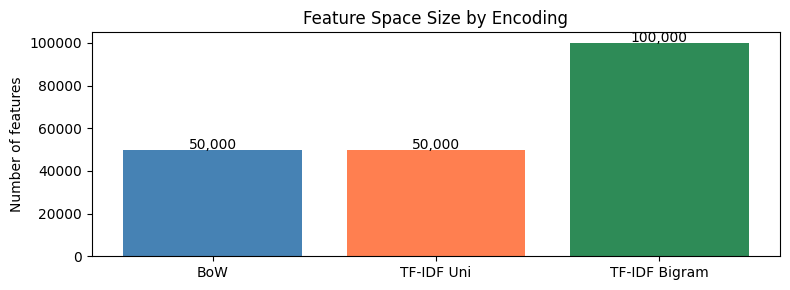

In [8]:
summary = pd.DataFrame([
    {'Encoding': 'BoW',           'Features': X_train_bow.shape[1],      'Density': density,     'Type': 'Integer counts'},
    {'Encoding': 'TF-IDF Uni',    'Features': X_train_tfidf_uni.shape[1],'Density': density_uni, 'Type': 'TF-IDF (1-gram)'},
    {'Encoding': 'TF-IDF Bigram', 'Features': X_train_tfidf_bi.shape[1], 'Density': density_bi,  'Type': 'TF-IDF (1-2 gram)'},
])
summary['Density'] = summary['Density'].map('{:.4%}'.format)
print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(summary['Encoding'], [X_train_bow.shape[1], X_train_tfidf_uni.shape[1], X_train_tfidf_bi.shape[1]],
       color=['steelblue', 'coral', 'seagreen'])
ax.set_ylabel('Number of features')
ax.set_title('Feature Space Size by Encoding')
for i, v in enumerate([X_train_bow.shape[1], X_train_tfidf_uni.shape[1], X_train_tfidf_bi.shape[1]]):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.savefig('../data/encoded/encoding_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

## Archivos generados en `data/encoded/`

| Archivo | Descripción |
|---|---|
| `X_train_bow.npz` / `X_test_bow.npz` | Matrices BoW |
| `X_train_tfidf_uni.npz` / `X_test_tfidf_uni.npz` | TF-IDF unigrama |
| `X_train_tfidf_bi.npz` / `X_test_tfidf_bi.npz` | TF-IDF bigrama |
| `bow_vectorizer.pkl` | Vectorizador BoW serializado |
| `tfidf_uni_vectorizer.pkl` | Vectorizador TF-IDF unigrama |
| `tfidf_bi_vectorizer.pkl` | Vectorizador TF-IDF bigrama |
| `y_train.npy` / `y_test.npy` | Etiquetas |